# Mixed-recording Evaluation

This notebook evaluates saved heart and lung models on mixed audio recordings (heart + lung).

Summary:
- Loads `heart_model.pkl` and `lung_model.pkl` plus their label encoders
- Extracts the shared 64-dimensional pooled feature vector from files in `dataset/Mix/`
- Runs both models on each mixed recording, saves `mix_evaluation_results.csv`, and reports metrics (accuracy, macro F1, confusion matrices)

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [2]:
# load trained models and label encoders
heart_model = joblib.load(
    "../heart_sound_classification/heart_model.pkl"
)

lung_model = joblib.load(
    "../lung_sound_classification/lung_model.pkl"
)

label_encoder_heart = joblib.load(
    "../heart_sound_classification/label_encoder_heart.pkl"
)

label_encoder_lung = joblib.load(
    "../lung_sound_classification/label_encoder_lung.pkl"
)

print("Models loaded successfully.")

Models loaded successfully.


In [3]:
# load mix dataset

mix_df = pd.read_csv("../dataset/Mix.csv")

print(mix_df.head())
print("Total mixed recordings:", len(mix_df))

  Gender      Heart Sound Type  Lung Sound Type Location Heart Sound ID  \
0      F  Late Systolic Murmur          Rhonchi     LUSB          H0001   
1      F                    S3           Normal      RLA          H0002   
2      M   Atrial Fibrillation           Normal      LMA          H0003   
3      F                    S3  Coarse Crackles     Apex          H0004   
4      M              AV Block    Fine Crackles     RUSB          H0005   

  Lung Sound ID Mixed Sound ID  
0         L0001          M0001  
1         L0002          M0002  
2         L0003          M0003  
3         L0004          M0004  
4         L0005          M0005  
Total mixed recordings: 145


In [4]:
# feature extraction function
def extract_features(path):

    audio, sr = librosa.load(path, sr=22050)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sr), axis=1)

    contrast = np.mean(librosa.feature.spectral_contrast(y=audio, sr=sr), axis=1)

    zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))
    rms = np.mean(librosa.feature.rms(y=audio))

    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))

    return np.hstack([
        mfcc_mean,
        mfcc_std,
        chroma,
        contrast,
        zcr,
        rms,
        centroid,
        bandwidth,
        rolloff
    ])

In [5]:
# evaluate mix reocrdings
results = []

mix_folder = "../dataset/Mix"

for _, row in mix_df.iterrows():

    mix_id = str(row["Mixed Sound ID"]).strip()

    mix_path = os.path.join(
        mix_folder,
        mix_id + ".wav"
    )

    if not os.path.exists(mix_path):
        print("Missing:", mix_path)
        continue

    try:

        features = extract_features(
            mix_path
        ).reshape(1, -1)

        # Heart prediction
        heart_pred_enc = heart_model.predict(
            features
        )[0]

        heart_pred = (
            label_encoder_heart
            .inverse_transform(
                [heart_pred_enc]
            )[0]
        )

        # Lung prediction
        lung_pred_enc = lung_model.predict(
            features
        )[0]

        lung_pred = (
            label_encoder_lung
            .inverse_transform(
                [lung_pred_enc]
            )[0]
        )

        results.append({

            "Mix_ID": mix_id,

            "True_Heart":
                str(row["Heart Sound Type"]),

            "Pred_Heart":
                str(heart_pred),

            "True_Lung":
                str(row["Lung Sound Type"]),

            "Pred_Lung":
                str(lung_pred)
        })

    except Exception as e:

        print("Error:", mix_path)
        print(e)


In [6]:
# results dataframe
results_df = pd.DataFrame(results)

print(results_df.head())

results_df.to_csv(
    "mix_evaluation_results.csv",
    index=False
)

print("Results saved.")


  Mix_ID            True_Heart Pred_Heart        True_Lung    Pred_Lung
0  M0001  Late Systolic Murmur     Normal          Rhonchi      Rhonchi
1  M0002                    S3     Normal           Normal       Normal
2  M0003   Atrial Fibrillation     Normal           Normal       Normal
3  M0004                    S3     Normal  Coarse Crackles  Pleural Rub
4  M0005              AV Block     Normal    Fine Crackles      Rhonchi
Results saved.


In [7]:
# heart accuracy
heart_acc = accuracy_score(
    results_df["True_Heart"],
    results_df["Pred_Heart"]
)
print("HEART ON MIX")
print("Accuracy:", heart_acc)

print(
    classification_report(
        results_df["True_Heart"],
        results_df["Pred_Heart"],
        zero_division=0
    )
)


HEART ON MIX
Accuracy: 0.18620689655172415
                       precision    recall  f1-score   support

             AV Block       0.00      0.00      0.00        13
  Atrial Fibrillation       0.00      0.00      0.00        15
Early Systolic Murmur       0.57      0.31      0.40        13
Late Diastolic Murmur       0.25      0.08      0.12        13
 Late Systolic Murmur       0.33      0.41      0.37        17
  Mid Systolic Murmur       0.57      0.29      0.38        14
               Normal       0.10      0.77      0.17        13
                   S3       0.33      0.07      0.11        15
                   S4       0.00      0.00      0.00        16
          Tachycardia       0.00      0.00      0.00        16

             accuracy                           0.19       145
            macro avg       0.22      0.19      0.16       145
         weighted avg       0.21      0.19      0.15       145



In [8]:
# lung accuracy
lung_acc = accuracy_score(
    results_df["True_Lung"],
    results_df["Pred_Lung"]
)

print("LUNG ON MIX")
print("Accuracy:", lung_acc)

print(
    classification_report(
        results_df["True_Lung"],
        results_df["Pred_Lung"],
        zero_division=0
    )
)

LUNG ON MIX
Accuracy: 0.5310344827586206
                 precision    recall  f1-score   support

Coarse Crackles       0.63      0.63      0.63        19
  Fine Crackles       0.33      0.18      0.24        22
         Normal       0.35      0.68      0.46        28
    Pleural Rub       0.90      0.36      0.51        25
        Rhonchi       0.56      0.78      0.65        23
       Wheezing       0.83      0.54      0.65        28

       accuracy                           0.53       145
      macro avg       0.60      0.53      0.53       145
   weighted avg       0.61      0.53      0.53       145



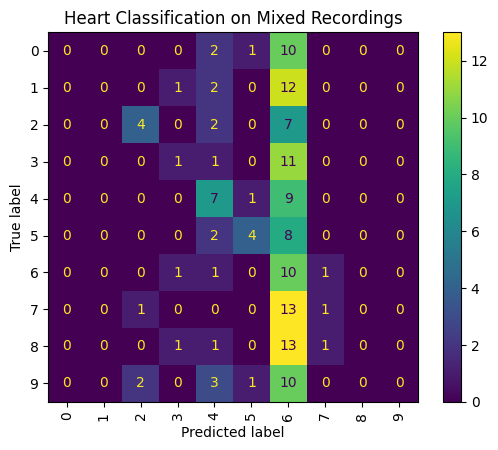

In [9]:
# confusion matrix for heart
cm_heart = confusion_matrix(
    results_df["True_Heart"],
    results_df["Pred_Heart"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_heart
)

disp.plot(
    xticks_rotation=90
)

plt.title(
    "Heart Classification on Mixed Recordings"
)

plt.show()

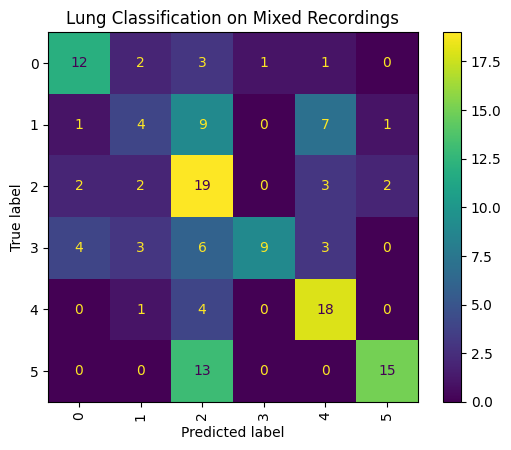

In [10]:
# confusion matrix for lung
cm_lung = confusion_matrix(
    results_df["True_Lung"],
    results_df["Pred_Lung"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lung
)

disp.plot(
    xticks_rotation=90
)

plt.title(
    "Lung Classification on Mixed Recordings"
)

plt.show()

In [11]:
# final summary
print(
    f"Heart Accuracy on Mix: {heart_acc:.4f}"
)

print(
    f"Lung Accuracy on Mix: {lung_acc:.4f}"
)

Heart Accuracy on Mix: 0.1862
Lung Accuracy on Mix: 0.5310


In [12]:
from sklearn.metrics import f1_score

heart_f1 = f1_score(
    results_df["True_Heart"],
    results_df["Pred_Heart"],
    average="macro"
)

lung_f1 = f1_score(
    results_df["True_Lung"],
    results_df["Pred_Lung"],
    average="macro"
)

print("Heart Macro F1:", heart_f1)
print("Lung Macro F1:", lung_f1)

Heart Macro F1: 0.15505453966220487
Lung Macro F1: 0.5252154635060781


In [16]:
heart_original_f1 = 0.61   # from Heart experiment
lung_original_f1 = 0.79   # from Lung experiment
heart_original_acc = 0.75  # from Heart experiment
lung_original_acc = 0.90   # from Lung experiment
comparison = pd.DataFrame({
    "Task": [
        "Heart Original",
        "Heart Mixed",
        "Lung Original",
        "Lung Mixed"
    ],
    "Accuracy": [
        heart_original_acc,
        heart_acc,
        lung_original_acc,
        lung_acc
    ],
    "Macro_F1": [
        heart_original_f1,
        heart_f1,
        lung_original_f1,
        lung_f1
    ]
})

print(comparison)

             Task  Accuracy  Macro_F1
0  Heart Original  0.750000  0.610000
1     Heart Mixed  0.186207  0.155055
2   Lung Original  0.900000  0.790000
3      Lung Mixed  0.531034  0.525215
